# Week 7 – Linear Regression From Scratch  
## California Housing Dataset (Kaggle Version)

### Implemented:
- Train-test split (manual)
- Feature scaling (manual)
- Gradient Descent (vectorized)
- Cost function (MSE)
- R² Score
- Normal Equation

No sklearn training used.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving housing.csv to housing (1).csv


In [2]:
import os
print(os.listdir())

['.config', 'housing.csv', 'housing (1).csv', 'sample_data']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



 **Data Preprocessing**


In [8]:
df = df.drop("ocean_proximity", axis=1)

In [10]:
X = df.drop("median_house_value", axis=1).values
y = df["median_house_value"].values.reshape(-1,1)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (20640, 8)
Target shape: (20640, 1)


**Train-Test Split**

In [11]:
def train_test_split(X, y, test_ratio=0.2):

    np.random.seed(42)
    n = X.shape[0]
    indices = np.random.permutation(n)
    test_size = int(n * test_ratio)

    test_idx = indices[:test_size]
    train_idx = indices[test_size:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16512, 8)
Test size: (4128, 8)


**Feature Scaling**

In [12]:
def standardize(X):
    mean = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - mean) / std, mean, std

X_train, mean, std = standardize(X_train)
X_test = (X_test - mean) / std

**Linear Regression From Scratch**

In [15]:
class LinearRegressionScratch:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs

    def initialize(self, n_features):
        self.w = np.zeros((n_features, 1))
        self.b = 0

    def compute_cost(self, X, y):
        n = X.shape[0]
        y_pred = X.dot(self.w) + self.b
        return (1/n) * np.sum((y_pred - y)**2)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.initialize(n_features)

        self.cost_history = []

        for i in range(self.epochs):

            y_pred = X.dot(self.w) + self.b

            dw = (2/n_samples) * X.T.dot(y_pred - y)
            db = (2/n_samples) * np.sum(y_pred - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)

            if i % 100 == 0:
                print(f"Epoch {i}, Cost: {cost}")

        return self

    def predict(self, X):
        return X.dot(self.w) + self.b

**Train Model**

In [16]:
model = LinearRegressionScratch(learning_rate=0.01, epochs=1000)
model.fit(X_train, y_train)

print("Learned Weights:\n", model.w)
print("Learned Bias:\n", model.b)

Epoch 0, Cost: 54314198801.94493
Epoch 100, Cost: 6757967628.14754
Epoch 200, Cost: 5596441976.273604
Epoch 300, Cost: 5367685580.991397
Epoch 400, Cost: 5216899044.289231
Epoch 500, Cost: 5109290194.887734
Epoch 600, Cost: 5031774680.140769
Epoch 700, Cost: 4975578511.524162
Epoch 800, Cost: 4934602834.723346
Epoch 900, Cost: 4904563288.952938
Learned Weights:
 [[-63366.12495145]
 [-68727.84224236]
 [ 17658.21308641]
 [-12898.17275721]
 [ 31219.48995289]
 [-41651.98770225]
 [ 29195.81798301]
 [ 78348.59902312]]
Learned Bias:
 207194.69338916749


**Model Evaluation**

In [17]:
y_pred_test = model.predict(X_test)

In [18]:
def mean_squared_error(y, y_pred):
    return np.mean((y - y_pred)**2)

mse = mean_squared_error(y_test, y_pred_test)
print("Test MSE:", mse)

Test MSE: nan


In [19]:
def r2_score(y, y_pred):
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - (ss_res/ss_tot)

r2 = r2_score(y_test, y_pred_test)
print("Test R²:", r2)

Test R²: nan


**Loss Curve Visualization**

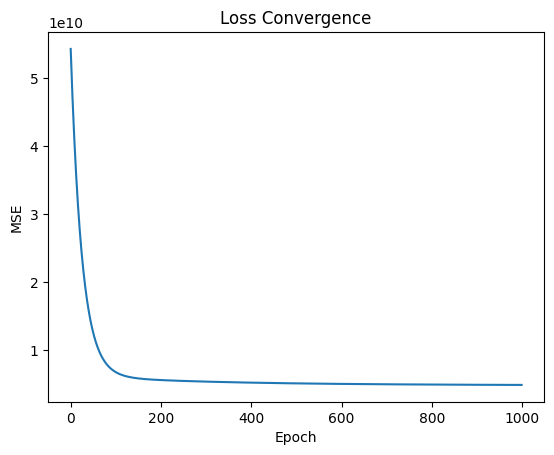

In [20]:
plt.plot(model.cost_history)
plt.title("Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

**Actual vs Predicted Plot**

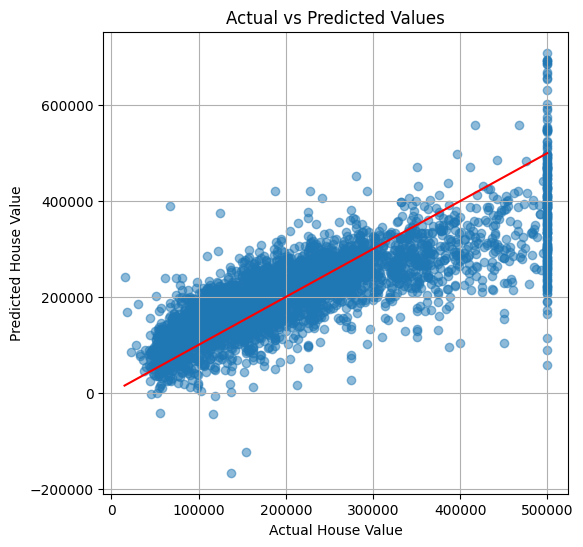

In [22]:
y_pred_test = model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

# Ideal line
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.grid(True)
plt.show()

**Residual Distribution Plot**

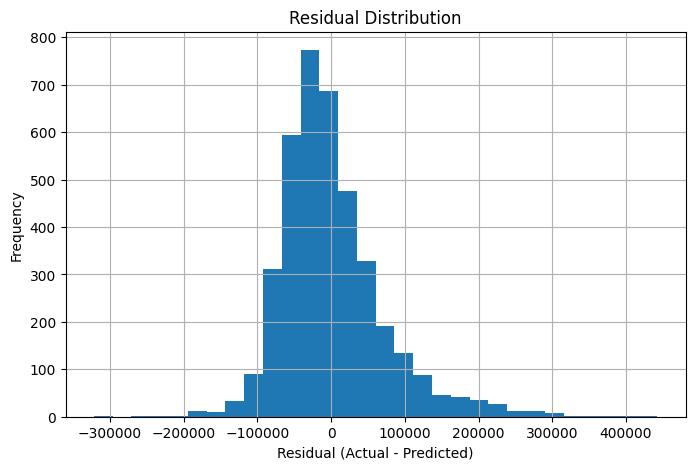

In [23]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

**Residual vs Predicted Plot**

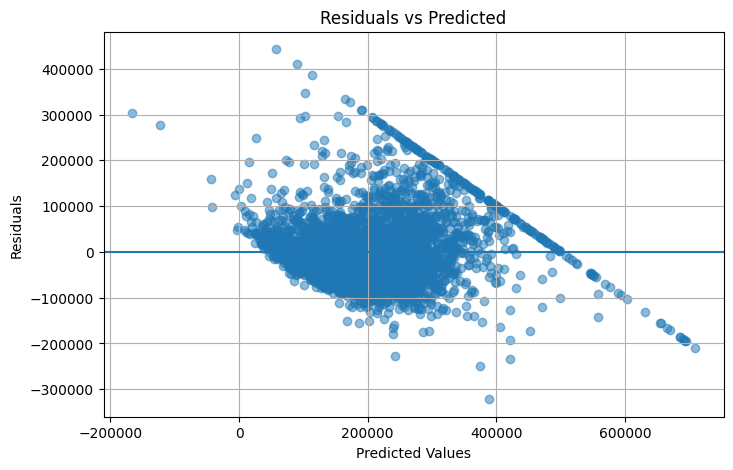

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid(True)
plt.show()

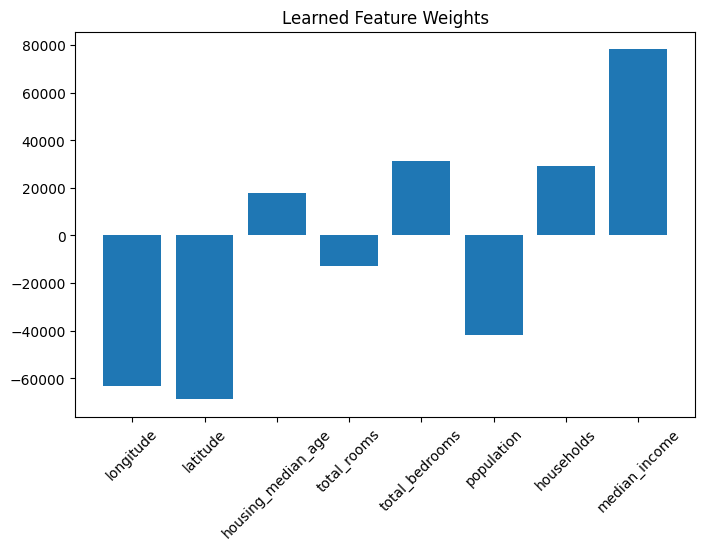

In [25]:
feature_names = df.drop("median_house_value", axis=1).columns

plt.figure(figsize=(8,5))
plt.bar(feature_names, model.w.flatten())
plt.xticks(rotation=45)
plt.title("Learned Feature Weights")
plt.show()

**Normal Equation**

In [21]:
def normal_equation(X, y):

    X_b = np.c_[np.ones((X.shape[0],1)), X]
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta

theta = normal_equation(X_train, y_train)
print("Normal Equation Parameters:\n", theta)

Normal Equation Parameters:
 [[207194.69373786]
 [-85503.21815336]
 [-90698.84880311]
 [ 14905.90644754]
 [-17805.41850057]
 [ 48712.34334124]
 [-43766.49115918]
 [ 17654.50065911]
 [ 77194.69946558]]
